# Notebook 02 — Estacionariedad, Descomposición STL y Cambio de Régimen
**TFM · Predicción de Ventas para Optimización de Stock**  
Familias: PVC · PE · PE-X (reticulado)  

**Objetivos de este notebook:**
1. Agregar las ventas a nivel mensual por familia
2. Test ADF (Dickey-Fuller Aumentado) + KPSS → determinar orden de integración *d*
3. Descomposición STL (Seasonal-Trend Decomposition using Loess) por familia
4. Detección de cambios de régimen estructural (ruptures: PELT + BinSeg)
5. Diagnóstico final: tabla resumen con recomendación de parámetros para SARIMA

In [1]:
# ── 0. Imports ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from statsmodels.tsa.stattools   import adfuller, kpss
from statsmodels.tsa.seasonal    import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import ruptures as rpt

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

FAMILIAS   = None          # Se rellena automáticamente tras cargar datos
COLORES    = {'PVC': '#2ecc71', 'PE': '#3498db', 'PE-X': '#e74c3c'}
ALPHA_SIGN = 0.05          # Nivel de significación para los tests

print('Imports OK')

Imports OK


## 1. Carga y agregación mensual

In [2]:
# ── 1. Carga de datos ────────────────────────────────────────────────────────
df = pd.read_excel('../data/processed/datos.xlsx')
df['FECHA'] = pd.to_datetime(df['FECHA'])

# Filtrar solo ventas
df_ventas = df[df['TIPO_OPERACION'] == 'VENTA'].copy()

# Crear índice de período mensual
df_ventas['PERIODO'] = df_ventas['FECHA'].dt.to_period('M')

# Agregar importe neto mensual por familia
# Resultado: DataFrame con índice mensual y una columna por familia
ventas_mensual = (
    df_ventas
    .groupby(['PERIODO', 'FAMILIA'])['IMPORTE_NETO']
    .sum()
    .unstack('FAMILIA')
    .sort_index()
)

# Rellenar meses sin ventas con 0 (puede ocurrir en PE-X en años tempranos)
ventas_mensual = ventas_mensual.fillna(0)

FAMILIAS = ventas_mensual.columns.tolist()

print(f'Período: {ventas_mensual.index[0]} → {ventas_mensual.index[-1]}')
print(f'Meses totales: {len(ventas_mensual)}')
print(f'Familias detectadas: {FAMILIAS}')
ventas_mensual.head()

Período: 2010-12 → 2026-02
Meses totales: 163
Familias detectadas: [106, 124, 233]


FAMILIA,106,124,233
PERIODO,,,
2010-12,0.0,0.0,85989.58
2011-04,0.0,0.0,2125.20
2011-06,0.0,0.0,13591.95
2012-08,0.0,0.0,5412.89
2012-09,0.0,0.0,46859.77


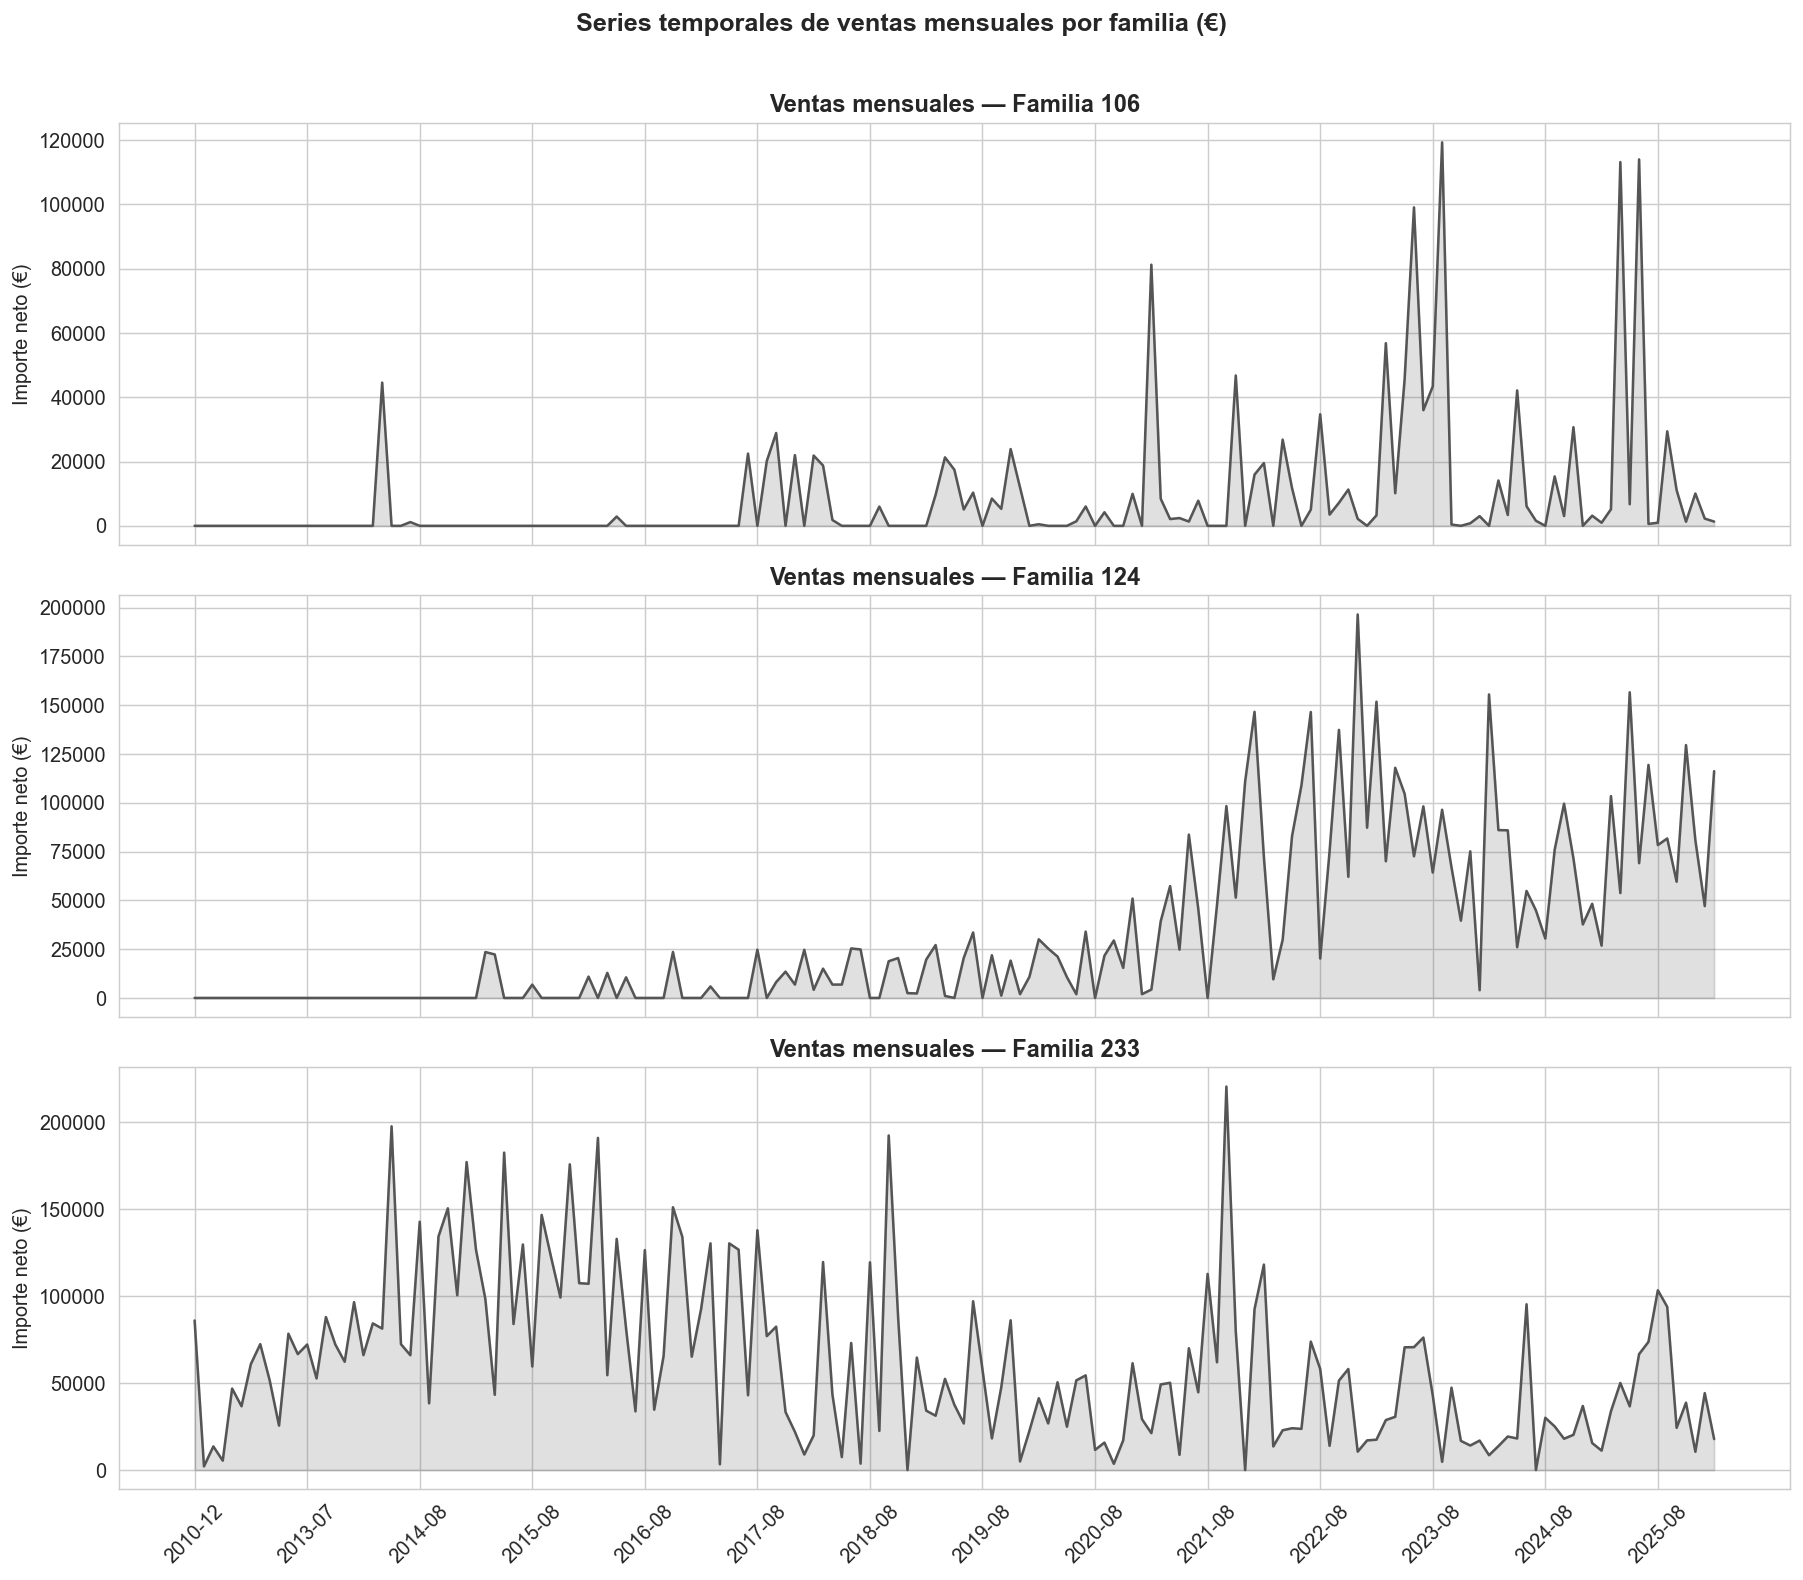

Figura guardada: figuras/02_series_brutas.pdf


In [3]:
# ── 1b. Visualización de las series brutas ───────────────────────────────────
fig, axes = plt.subplots(len(FAMILIAS), 1, figsize=(14, 4 * len(FAMILIAS)), sharex=True)
if len(FAMILIAS) == 1:
    axes = [axes]

for ax, familia in zip(axes, FAMILIAS):
    color = COLORES.get(familia, '#555')
    serie = ventas_mensual[familia]
    ax.fill_between(serie.index.astype(str), serie.values, alpha=0.18, color=color)
    ax.plot(serie.index.astype(str), serie.values, color=color, linewidth=1.4)
    ax.set_title(f'Ventas mensuales — Familia {familia}', fontweight='bold')
    ax.set_ylabel('Importe neto (€)')
    # Mostrar solo 1 de cada 12 etiquetas en el eje x
    ticks = range(0, len(serie), 12)
    ax.set_xticks([serie.index.astype(str)[i] for i in ticks])
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Series temporales de ventas mensuales por familia (€)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figuras/02_series_brutas.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/02_series_brutas.pdf')

## 2. Tests de estacionariedad: ADF + KPSS

### Marco teórico
- **ADF** (H₀: raíz unitaria → serie NO estacionaria). Rechazar H₀ ↔ serie estacionaria.
- **KPSS** (H₀: serie estacionaria). Rechazar H₀ ↔ serie NO estacionaria.
- Usamos ambos en conjunto para desambiguar:

| ADF p-valor | KPSS p-valor | Diagnóstico |
|---|---|---|
| < 0.05 | > 0.05 | **Estacionaria** (ambos coinciden) |
| > 0.05 | < 0.05 | **No estacionaria** → diferenciación necesaria |
| < 0.05 | < 0.05 | **Trend-stationary** → eliminar tendencia |
| > 0.05 | > 0.05 | **Contradicción** → revisar outliers o cambio de régimen |

In [4]:
# ── 2. Función de test combinado ADF + KPSS ──────────────────────────────────
def test_estacionariedad(serie: pd.Series, nombre: str, diff: int = 0) -> dict:
    """
    Aplica ADF y KPSS sobre 'serie' e imprime un resumen interpretado.
    Parámetros
    ----------
    serie  : Serie de pandas (valores numéricos, sin NaN)
    nombre : Etiqueta para los mensajes de salida
    diff   : Número de diferenciaciones aplicadas (solo informativo)
    Retorna
    -------
    dict con estadísticos, p-valores y diagnóstico
    """
    s = serie.dropna().values

    # ADF con regresión 'ct' (constante + tendencia)
    adf_stat, adf_p, adf_lags, _, adf_cv, _ = adfuller(s, autolag='AIC', regression='ct')

    # KPSS con regresión 'ct' (contraste de tendencia)
    kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression='ct', nlags='auto')

    # Diagnóstico combinado
    if adf_p < ALPHA_SIGN and kpss_p > ALPHA_SIGN:
        diag = '✅ Estacionaria'
        d_rec = diff
    elif adf_p >= ALPHA_SIGN and kpss_p <= ALPHA_SIGN:
        diag = '❌ No estacionaria → necesita diferenciación'
        d_rec = diff + 1
    elif adf_p < ALPHA_SIGN and kpss_p <= ALPHA_SIGN:
        diag = '⚠️  Trend-stationary → considerar log o eliminar tendencia'
        d_rec = diff
    else:
        diag = '❓ Contradictorios → revisar outliers / cambio de régimen'
        d_rec = diff

    tag = f'[{nombre}  |  diff={diff}]'
    print(f'{tag}')
    print(f'  ADF  stat={adf_stat:8.4f}  p={adf_p:.4f}  lags={adf_lags}'
          f'  CV5%={adf_cv["5%"]:.4f}')
    print(f'  KPSS stat={kpss_stat:8.4f}  p={kpss_p:.4f}  lags={kpss_lags}'
          f'  CV5%={kpss_cv["5%"]:.4f}')
    print(f'  → {diag}  |  d recomendado = {d_rec}')
    print()

    return {
        'familia': nombre, 'diff': diff,
        'adf_stat': adf_stat, 'adf_p': adf_p,
        'kpss_stat': kpss_stat, 'kpss_p': kpss_p,
        'diagnostico': diag, 'd_recomendado': d_rec
    }


# ── 2b. Aplicar sobre serie original y diferenciada ──────────────────────────
resultados_tests = []

for familia in FAMILIAS:
    serie_orig = ventas_mensual[familia]

    # Serie original
    res0 = test_estacionariedad(serie_orig, familia, diff=0)
    resultados_tests.append(res0)

    # Primera diferencia regular
    res1 = test_estacionariedad(serie_orig.diff(1), familia, diff=1)
    resultados_tests.append(res1)

    # Diferencia regular + diferencia estacional (si procede)
    res2 = test_estacionariedad(serie_orig.diff(1).diff(12), familia, diff='1+12')
    resultados_tests.append(res2)
    print('─' * 60)

df_tests = pd.DataFrame(resultados_tests)
print('\nResumen en tabla:')
df_tests[['familia','diff','adf_p','kpss_p','diagnostico','d_recomendado']]

[106  |  diff=0]
  ADF  stat= -5.7866  p=0.0000  lags=4  CV5%=-3.4387
  KPSS stat=  0.0500  p=0.1000  lags=6  CV5%=0.1460
  → ✅ Estacionaria  |  d recomendado = 0

[106  |  diff=1]
  ADF  stat= -6.4570  p=0.0000  lags=9  CV5%=-3.4398
  KPSS stat=  0.0133  p=0.1000  lags=3  CV5%=0.1460
  → ✅ Estacionaria  |  d recomendado = 1

[106  |  diff=1+12]
  ADF  stat= -6.4553  p=0.0000  lags=12  CV5%=-3.4430
  KPSS stat=  0.0136  p=0.1000  lags=3  CV5%=0.1460
  → ✅ Estacionaria  |  d recomendado = 1+12

────────────────────────────────────────────────────────────
[124  |  diff=0]
  ADF  stat= -2.0501  p=0.5739  lags=6  CV5%=-3.4390
  KPSS stat=  0.2476  p=0.0100  lags=6  CV5%=0.1460
  → ❌ No estacionaria → necesita diferenciación  |  d recomendado = 1

[124  |  diff=1]
  ADF  stat=-10.3527  p=0.0000  lags=5  CV5%=-3.4390
  KPSS stat=  0.0898  p=0.1000  lags=36  CV5%=0.1460
  → ✅ Estacionaria  |  d recomendado = 1

[124  |  diff=1+12]
  ADF  stat= -4.1893  p=0.0046  lags=12  CV5%=-3.4430
  KPSS s

C:\Users\a.abasolo\AppData\Local\Temp\ipykernel_18384\1969260229.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression='ct', nlags='auto')
C:\Users\a.abasolo\AppData\Local\Temp\ipykernel_18384\1969260229.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression='ct', nlags='auto')
C:\Users\a.abasolo\AppData\Local\Temp\ipykernel_18384\1969260229.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression='ct', nlags='auto')
C:\Users\a.abasolo\AppData\Local\Temp\ip

,familia,diff,adf_p,kpss_p,diagnostico,d_recomendado
0,106,0,6.097257e-06,0.100000,✅ Estacionaria,0
1,106,1,2.293426e-07,0.100000,✅ Estacionaria,1
2,106,1+12,2.313164e-07,0.100000,✅ Estacionaria,1+12
3,124,0,5.739153e-01,0.010000,❌ No estacionaria → necesita diferenciación,1
4,124,1,4.241492e-16,0.100000,✅ Estacionaria,1
5,124,1+12,4.646012e-03,0.100000,✅ Estacionaria,1+12
6,233,0,9.776822e-04,0.081011,✅ Estacionaria,0
7,233,1,3.794200e-11,0.100000,✅ Estacionaria,1
8,233,1+12,5.193330e-05,0.100000,✅ Estacionaria,1+12


## 3. Descomposición STL por familia

STL (Cleveland et al., 1990) descompone la serie en:
$$Y_t = T_t + S_t + R_t$$
- **$T_t$** — tendencia suavizada (LOESS)
- **$S_t$** — componente estacional (período = 12 meses)
- **$R_t$** — residuo

Usamos `robust=True` para atenuar el efecto de outliers en el ajuste LOESS.

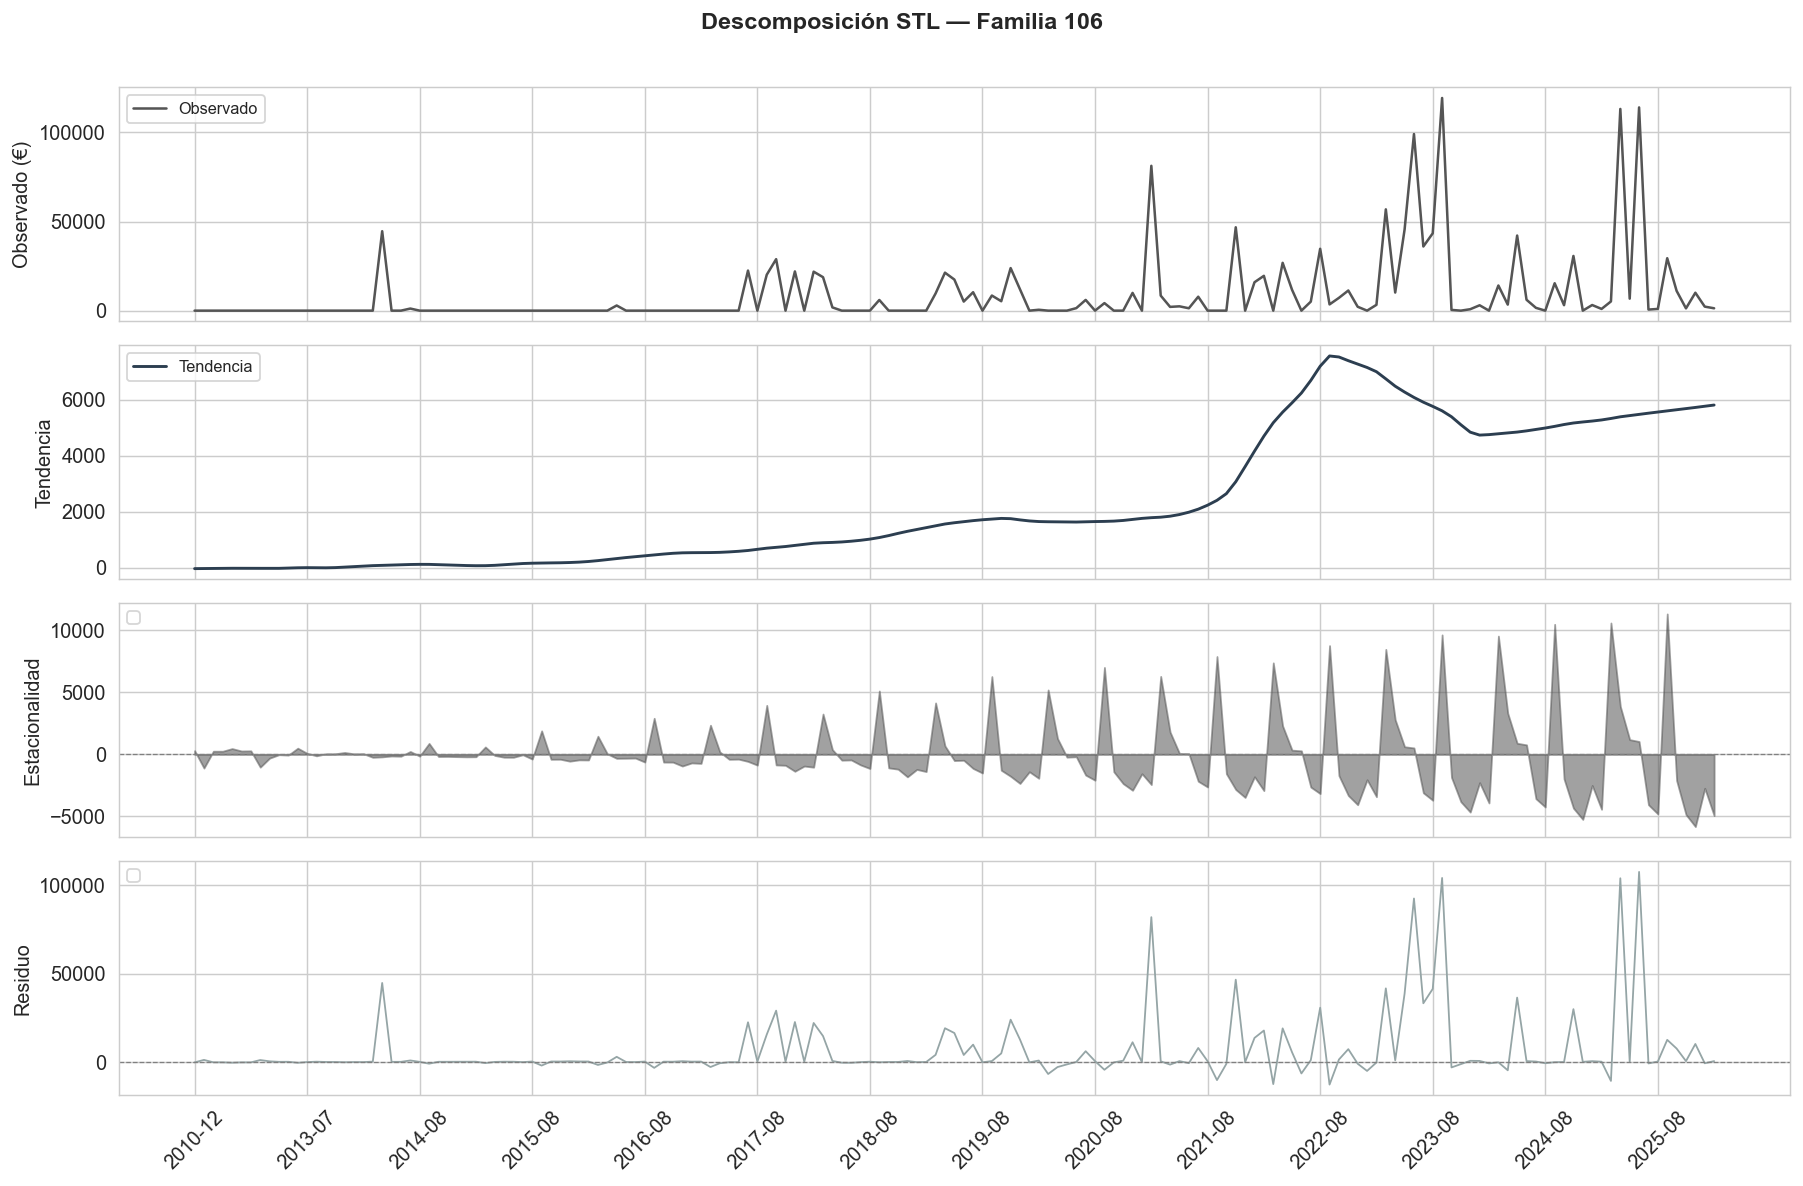

Figura guardada: ../figuras/02_STL_106.pdf



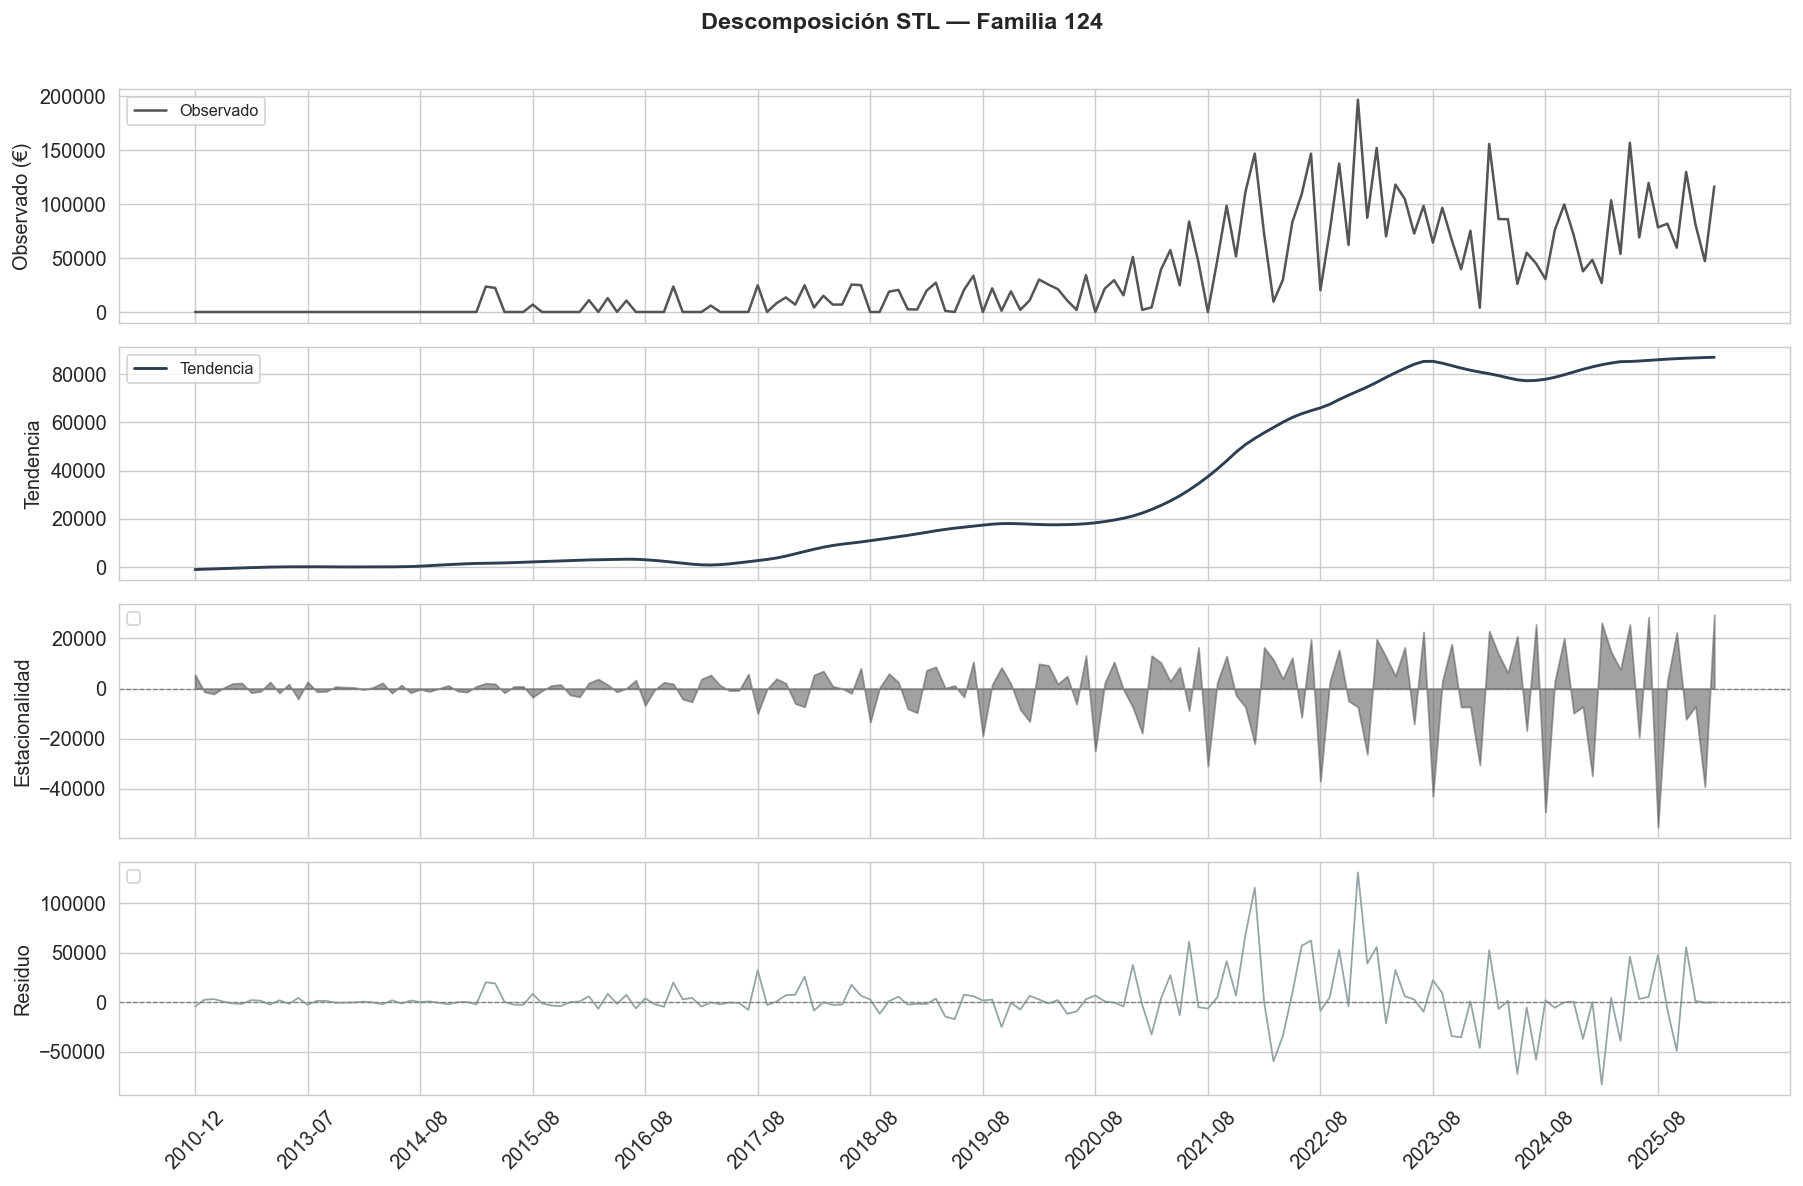

Figura guardada: ../figuras/02_STL_124.pdf



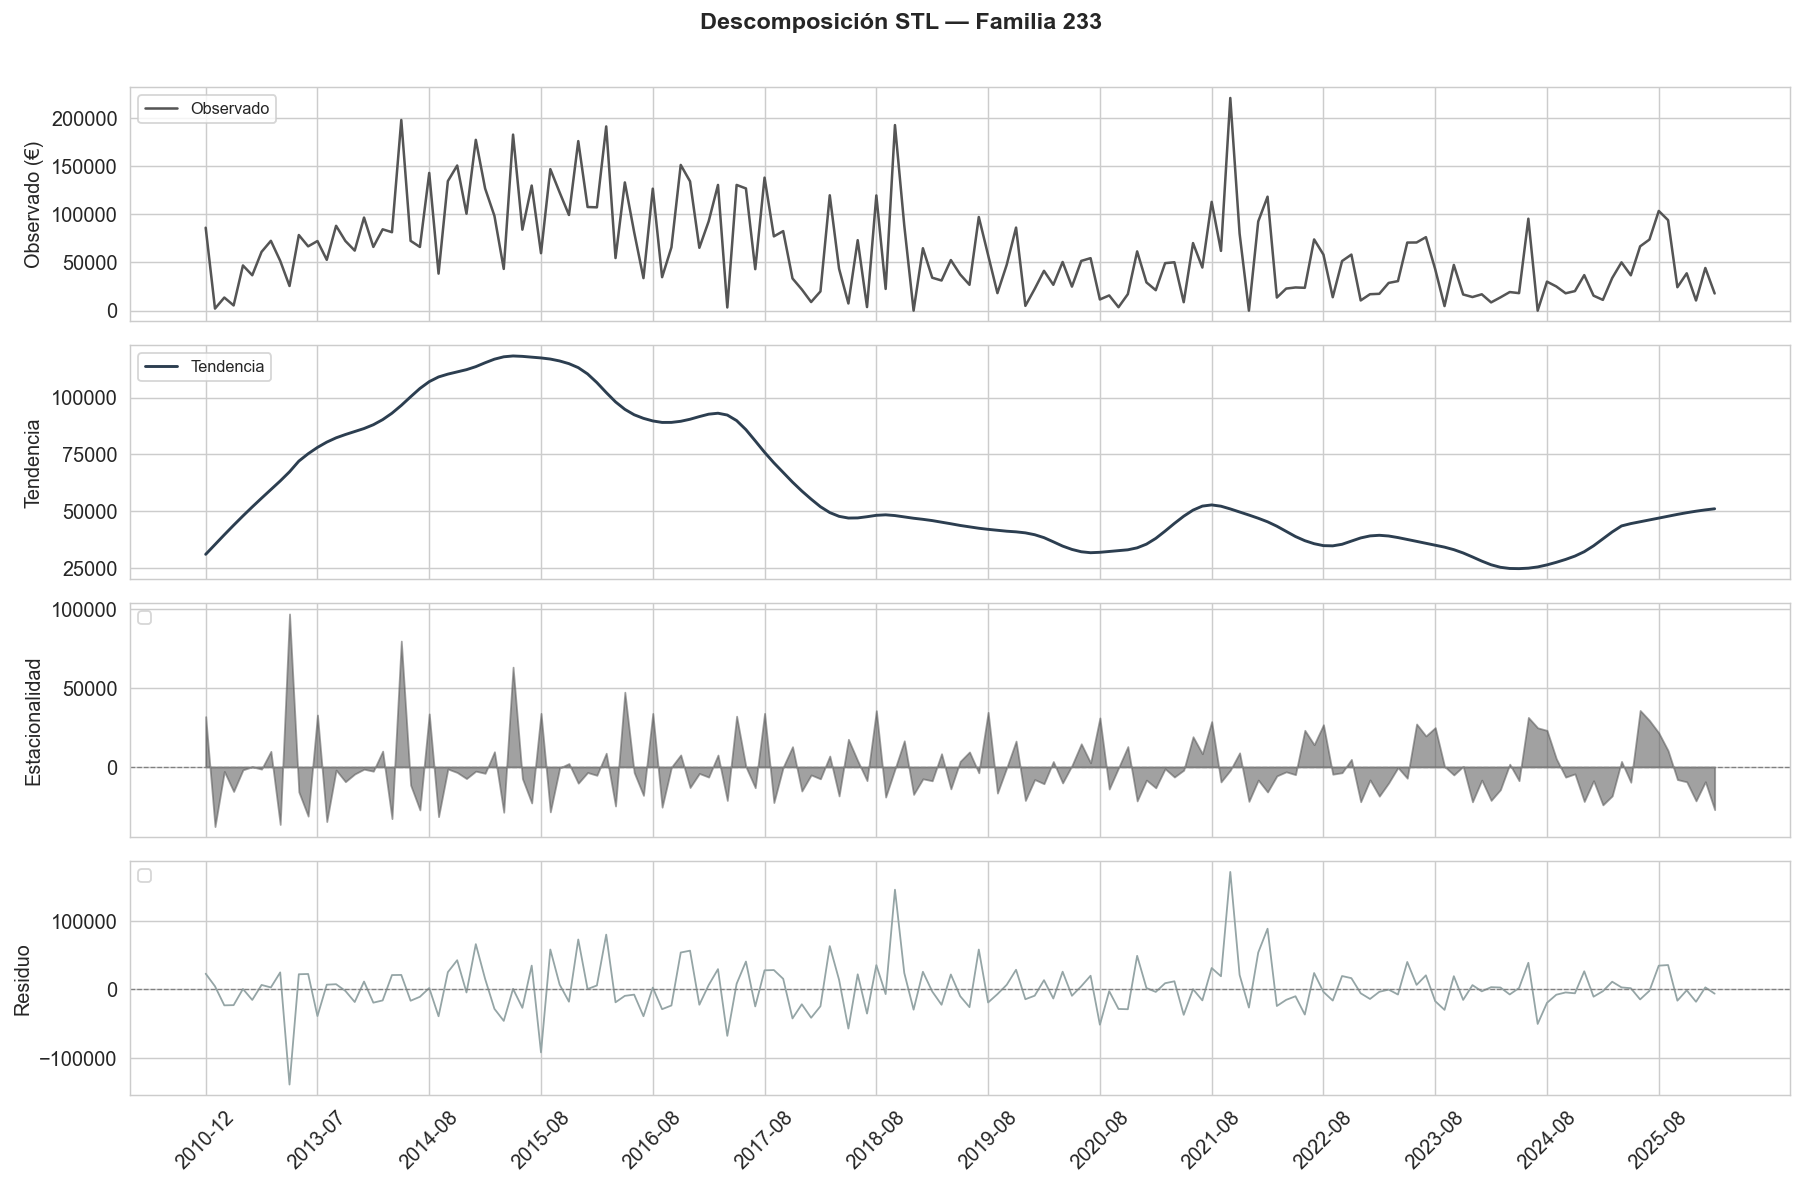

Figura guardada: ../figuras/02_STL_233.pdf



In [5]:
# ── 3. STL por familia ───────────────────────────────────────────────────────
stl_resultados = {}

for familia in FAMILIAS:
    serie = ventas_mensual[familia].astype(float)
    # period=12 → estacionalidad anual
    # seasonal=13 → ventana del suavizado estacional (debe ser impar, >= period+2)
    stl = STL(serie, period=12, seasonal=13, robust=True)
    res = stl.fit()
    stl_resultados[familia] = res

    # ── Gráfico de componentes ──
    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
    color = COLORES.get(familia, '#555')

    idx_str = ventas_mensual.index.astype(str)

    axes[0].plot(idx_str, res.observed,  color=color,   lw=1.4, label='Observado')
    axes[0].set_ylabel('Observado (€)');

    axes[1].plot(idx_str, res.trend,     color='#2c3e50', lw=1.6, label='Tendencia')
    axes[1].set_ylabel('Tendencia');

    axes[2].fill_between(idx_str, res.seasonal, alpha=0.55, color=color)
    axes[2].axhline(0, color='grey', lw=0.7, ls='--')
    axes[2].set_ylabel('Estacionalidad');

    axes[3].plot(idx_str, res.resid, color='#95a5a6', lw=1.0)
    axes[3].axhline(0, color='grey', lw=0.7, ls='--')
    axes[3].set_ylabel('Residuo');

    for ax in axes:
        ticks = range(0, len(idx_str), 12)
        ax.set_xticks([idx_str[i] for i in ticks])
        ax.tick_params(axis='x', rotation=45)
        ax.legend(loc='upper left', fontsize=9)

    plt.suptitle(f'Descomposición STL — Familia {familia}',
                 fontweight='bold', fontsize=13, y=1.01)
    plt.tight_layout()
    fname = f'../figuras/02_STL_{familia}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname}\n')

In [6]:
# ── 3b. Tabla de métricas STL ────────────────────────────────────────────────
# Cuantificamos cuánto aporta cada componente a la varianza total

metricas_stl = []
for familia, res in stl_resultados.items():
    var_total     = np.var(res.observed)
    var_tendencia = np.var(res.trend)
    var_estac     = np.var(res.seasonal)
    var_residuo   = np.var(res.resid)

    # Fuerza de la estacionalidad (Wang et al., 2006)
    # F_S = max(0, 1 - Var(R) / Var(S+R))
    F_S = max(0, 1 - var_residuo / np.var(res.seasonal + res.resid))

    # Fuerza de la tendencia
    # F_T = max(0, 1 - Var(R) / Var(T+R))
    F_T = max(0, 1 - var_residuo / np.var(res.trend + res.resid))

    metricas_stl.append({
        'Familia'          : familia,
        '% var Tendencia'  : round(100 * var_tendencia / var_total, 1),
        '% var Estacional' : round(100 * var_estac     / var_total, 1),
        '% var Residuo'    : round(100 * var_residuo   / var_total, 1),
        'F_S (fuerza est.)': round(F_S, 3),
        'F_T (fuerza tend.)': round(F_T, 3),
    })

df_stl = pd.DataFrame(metricas_stl)
print('Métricas STL por familia:')
df_stl.set_index('Familia')

Métricas STL por familia:


,% var Tendencia,% var Estacional,% var Residuo,F_S (fuerza est.),F_T (fuerza tend.)
Familia,,,,,
106,1.3,2.3,88.8,0.045,0.075
124,60.5,9.8,35.2,0.052,0.644
233,35.7,18.8,54.0,0.146,0.404


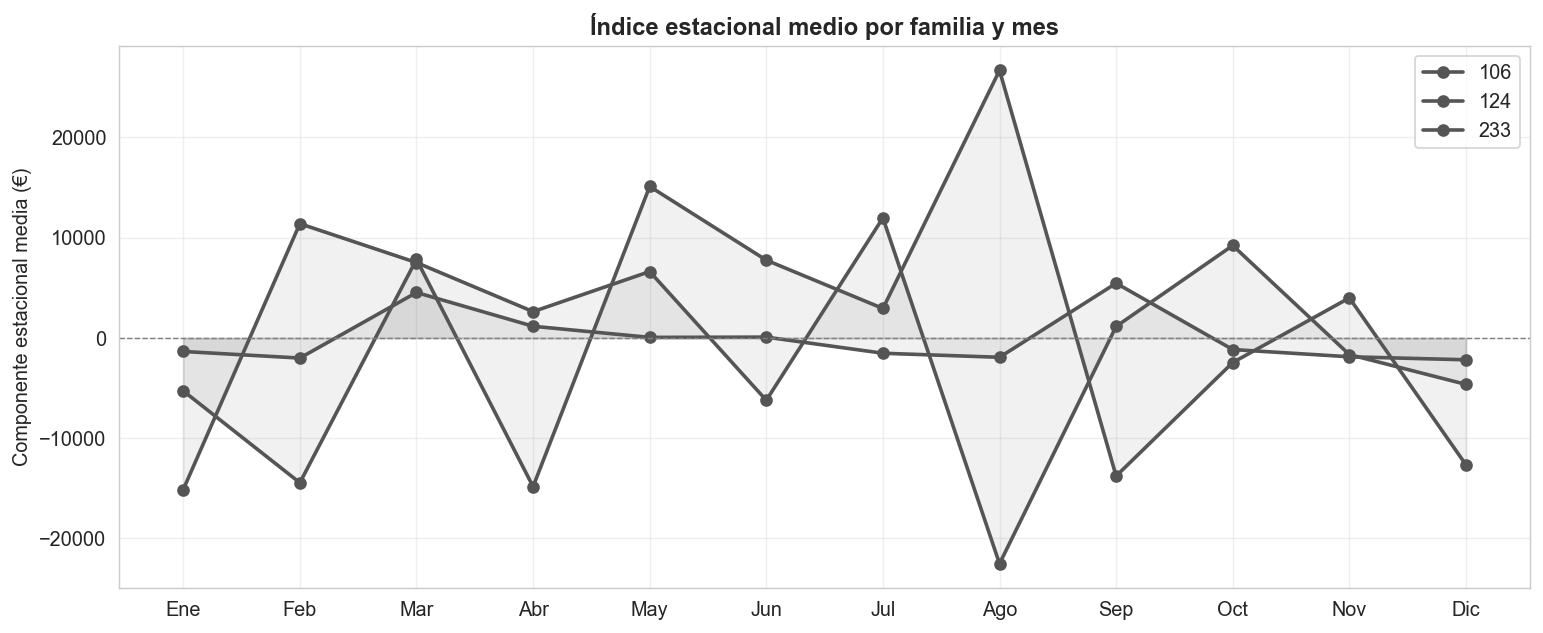

Figura guardada: figuras/02_perfil_estacional.pdf


In [7]:
# ── 3c. Perfil estacional medio (índice estacional por mes) ──────────────────
# Permite cuantificar en qué meses se concentra la demanda de cada familia

fig, ax = plt.subplots(figsize=(12, 5))
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

for familia in FAMILIAS:
    res = stl_resultados[familia]
    # Extraer componente estacional
    s_component = pd.Series(res.seasonal,
                            index=ventas_mensual.index)
    # Agrupar por mes y calcular media
    s_component_df = s_component.to_frame('S')
    s_component_df['mes'] = [p.month for p in s_component_df.index]
    perfil = s_component_df.groupby('mes')['S'].mean()

    color = COLORES.get(familia, '#555')
    ax.plot(meses, perfil.values, marker='o', lw=2,
            color=color, label=familia)
    ax.fill_between(meses, perfil.values, alpha=0.08, color=color)

ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_title('Índice estacional medio por familia y mes', fontweight='bold')
ax.set_ylabel('Componente estacional media (€)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figuras/02_perfil_estacional.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/02_perfil_estacional.pdf')

## 4. Detección de cambios de régimen estructural

Usamos la librería **`ruptures`** con dos algoritmos:
- **PELT** (`rbf`): penalización automática, coste O(n). Detecta número variable de puntos de ruptura.
- **BinSeg** (`l2`): búsqueda binaria, fijamos `n_bkps=2` (dos rupturas candidatas: crisis y COVID).

Los puntos de ruptura se interpretan como cambios en media o varianza de la serie de tendencia (no de la serie bruta, para evitar confundir ruptura con estacionalidad).

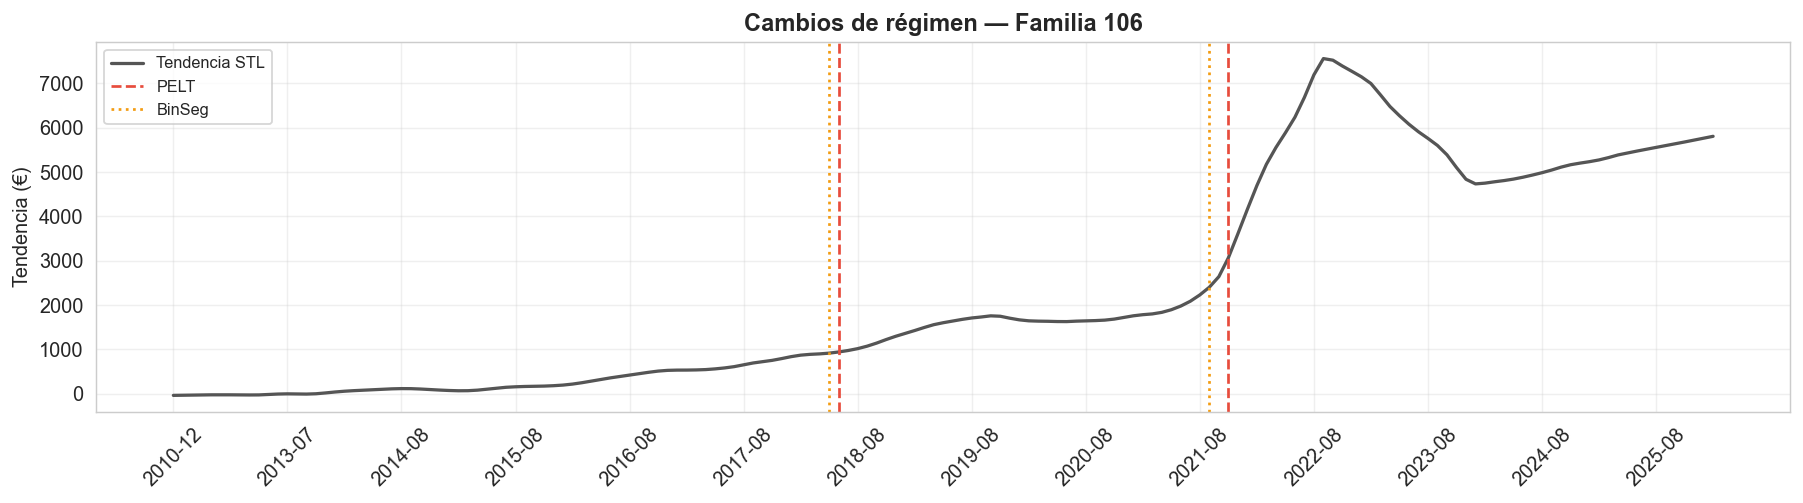

106 — PELT: ['2018-06', '2021-11']  |  BinSeg: ['2018-05', '2021-09']
Figura guardada: ../figuras/02_regimen_106.pdf



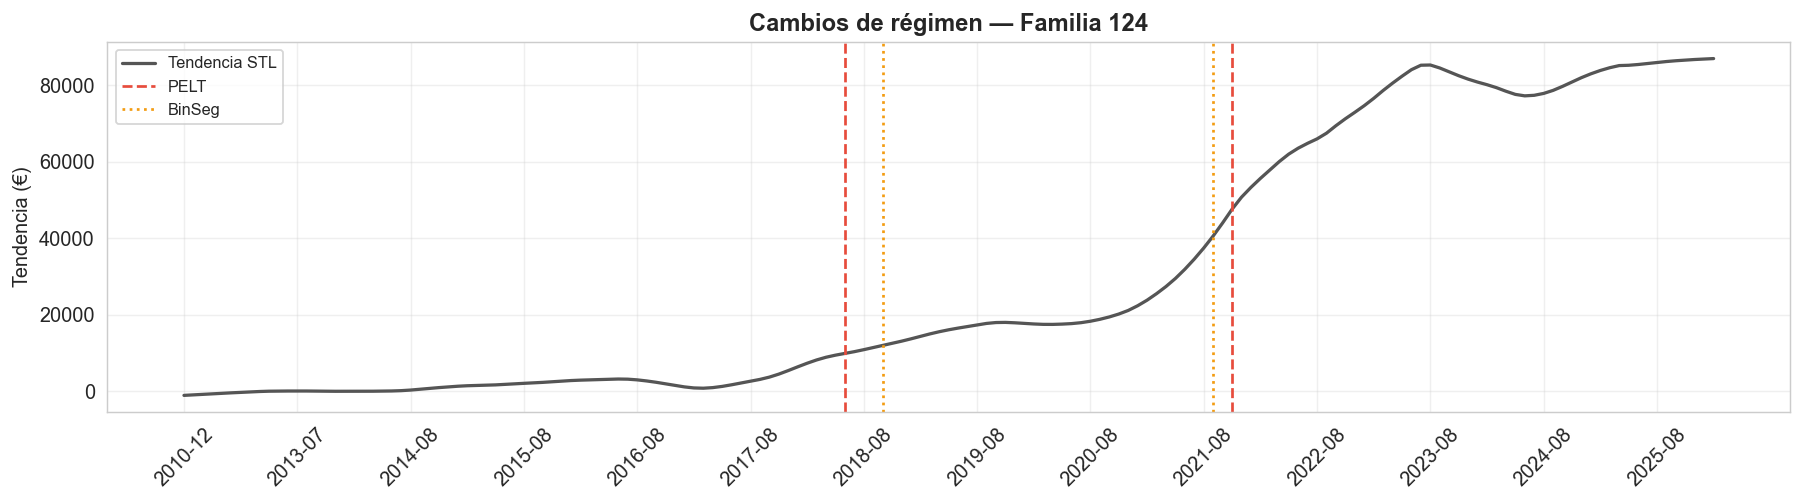

124 — PELT: ['2018-06', '2021-11']  |  BinSeg: ['2018-10', '2021-09']
Figura guardada: ../figuras/02_regimen_124.pdf



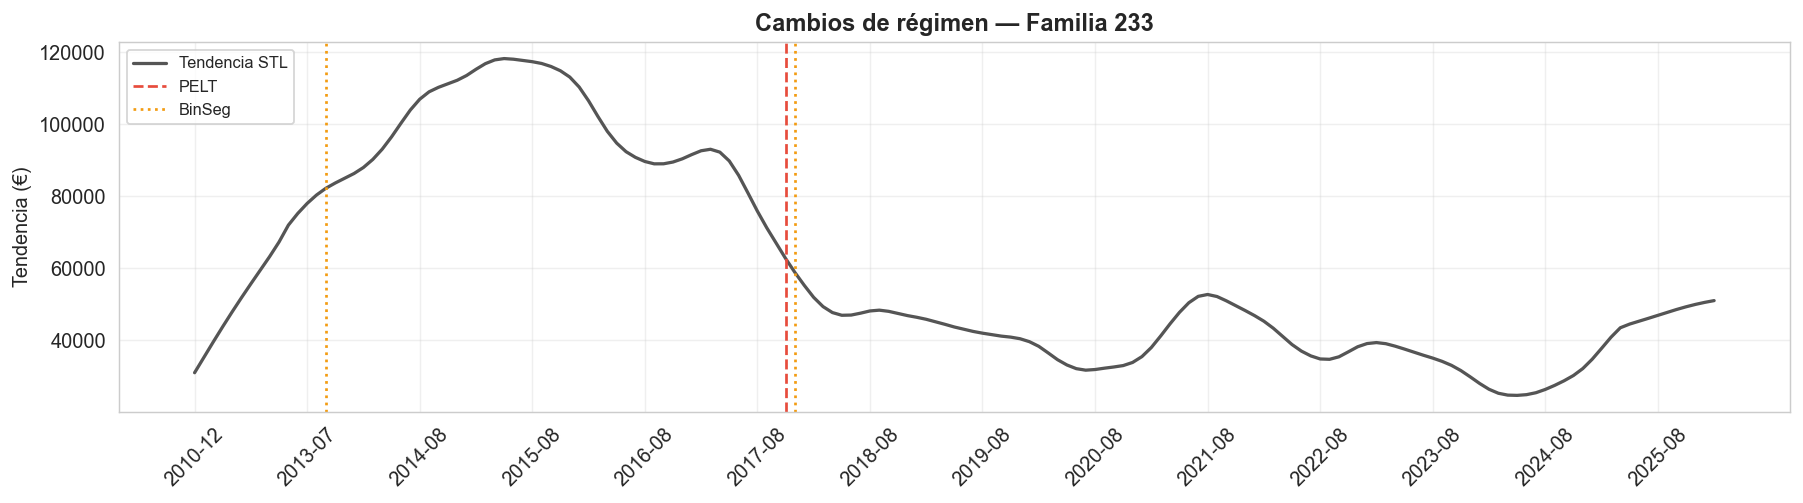

233 — PELT: ['2017-11']  |  BinSeg: ['2013-10', '2017-12']
Figura guardada: ../figuras/02_regimen_233.pdf



In [8]:
# ── 4. Detección de cambios de régimen ──────────────────────────────────────
cambios_regimen = {}

for familia in FAMILIAS:
    res   = stl_resultados[familia]
    trend = res.trend  # Usamos la tendencia STL, no la serie bruta
    idx   = ventas_mensual.index

    signal = trend.values.reshape(-1, 1)

    # PELT con penalización automática
    pelt = rpt.Pelt(model='rbf', min_size=12, jump=1).fit(signal)
    bps_pelt = pelt.predict(pen=10)
    bps_pelt_fechas = [str(idx[i-1]) for i in bps_pelt if i < len(idx)]

    # BinSeg con n=2 rupturas
    bseg = rpt.Binseg(model='l2', min_size=12).fit(signal)
    bps_bseg = bseg.predict(n_bkps=2)
    bps_bseg_fechas = [str(idx[i-1]) for i in bps_bseg if i < len(idx)]

    cambios_regimen[familia] = {
        'pelt': bps_pelt_fechas,
        'binseg': bps_bseg_fechas
    }

    # ── Gráfico ──
    fig, ax = plt.subplots(figsize=(14, 4))
    color = COLORES.get(familia, '#555')
    idx_str = idx.astype(str)

    ax.plot(idx_str, trend, color=color, lw=1.8, label='Tendencia STL')

    # Marcar rupturas PELT
    for bp in bps_pelt[:-1]:
        ax.axvline(x=idx_str[bp-1], color='#e74c3c', lw=1.5,
                   ls='--', label='PELT' if bp == bps_pelt[0] else '')

    # Marcar rupturas BinSeg
    for bp in bps_bseg[:-1]:
        ax.axvline(x=idx_str[bp-1], color='#f39c12', lw=1.5,
                   ls=':', label='BinSeg' if bp == bps_bseg[0] else '')

    ticks = range(0, len(idx_str), 12)
    ax.set_xticks([idx_str[i] for i in ticks])
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f'Cambios de régimen — Familia {familia}', fontweight='bold')
    ax.set_ylabel('Tendencia (€)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f'../figuras/02_regimen_{familia}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

    print(f'{familia} — PELT: {bps_pelt_fechas}  |  BinSeg: {bps_bseg_fechas}')
    print(f'Figura guardada: {fname}\n')

## 5. ACF y PACF de los residuos STL

Analizamos el residuo de la descomposición STL para detectar correlación remanente.  
Si los residuos muestran ACF/PACF significativa, habrá que modelizar $R_t$ con un componente ARMA.

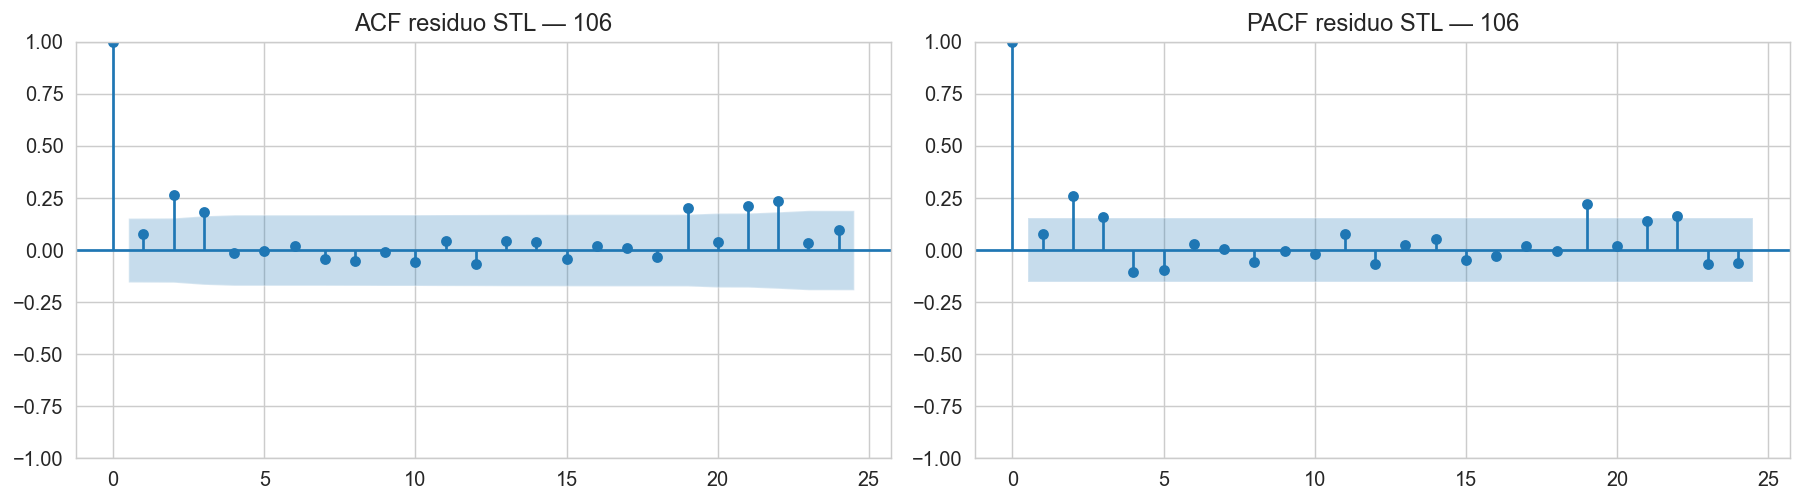

Figura guardada: ../figuras/02_acf_pacf_residuo_106.pdf



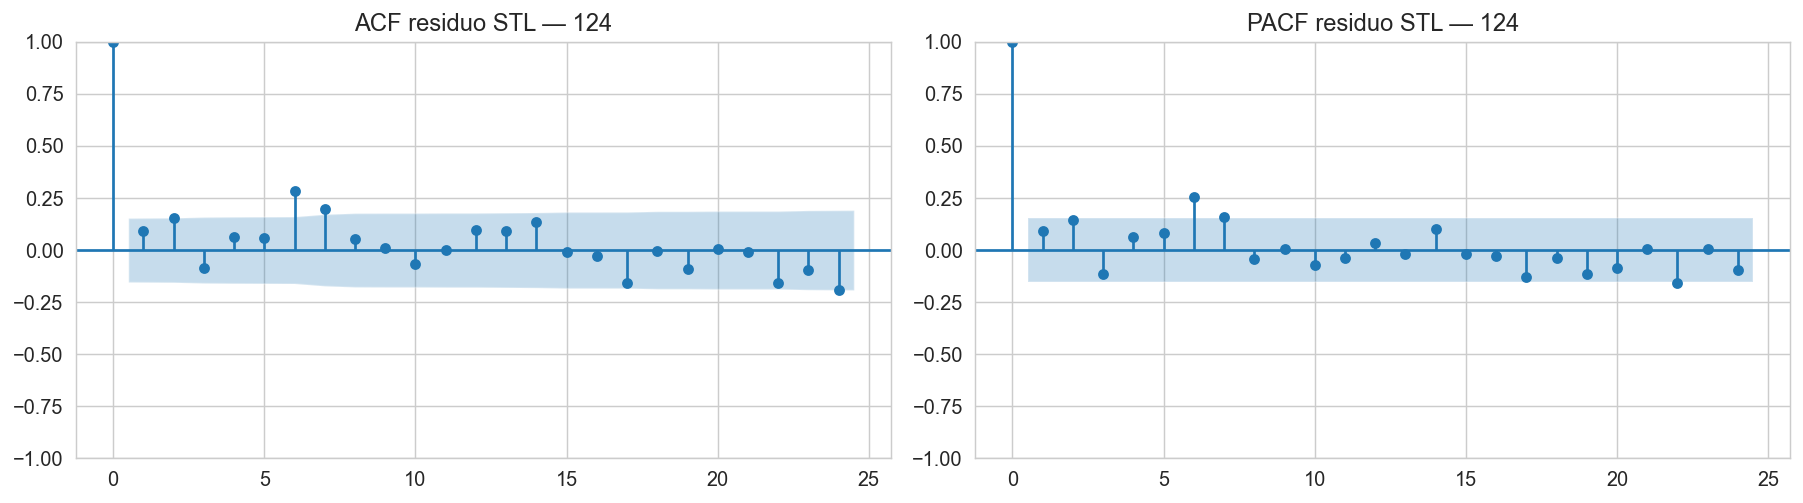

Figura guardada: ../figuras/02_acf_pacf_residuo_124.pdf



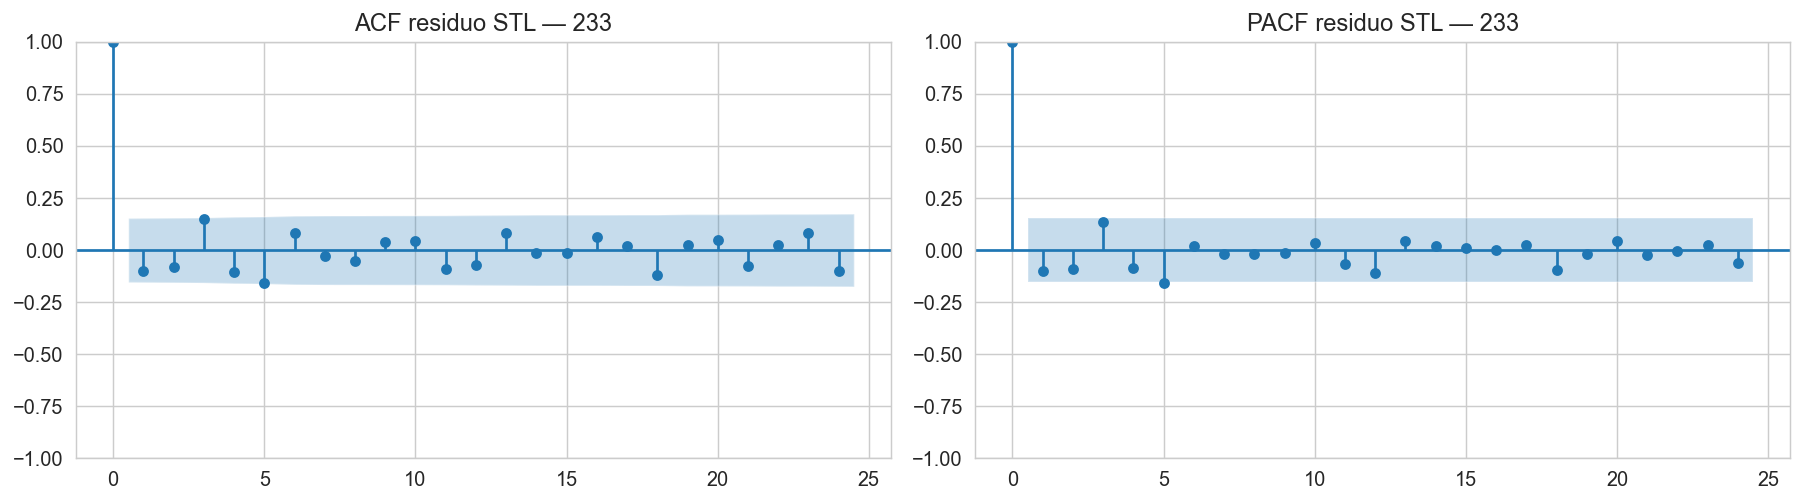

Figura guardada: ../figuras/02_acf_pacf_residuo_233.pdf



In [9]:
# ── 5. ACF + PACF del residuo STL ────────────────────────────────────────────
for familia in FAMILIAS:
    residuo = stl_resultados[familia].resid
    residuo_clean = pd.Series(residuo).dropna()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(residuo_clean,  lags=24, ax=ax1, alpha=0.05,
             title=f'ACF residuo STL — {familia}')
    plot_pacf(residuo_clean, lags=24, ax=ax2, alpha=0.05,
              method='ywm',
              title=f'PACF residuo STL — {familia}')

    plt.tight_layout()
    fname = f'../figuras/02_acf_pacf_residuo_{familia}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname}\n')

## 6. Tabla resumen diagnóstico → parámetros SARIMA recomendados

In [10]:
# ── 6. Tabla diagnóstico final ───────────────────────────────────────────────
print('=' * 75)
print('DIAGNÓSTICO FINAL — Parámetros recomendados para modelado')
print('=' * 75)

for familia in FAMILIAS:
    # Recuperar resultado del test a nivel diff=0
    adf_orig  = next(r for r in resultados_tests
                     if r['familia'] == familia and r['diff'] == 0)
    adf_d1    = next(r for r in resultados_tests
                     if r['familia'] == familia and r['diff'] == 1)

    stl_m = next(m for m in metricas_stl if m['Familia'] == familia)
    cr    = cambios_regimen[familia]

    d_rec = 1 if adf_orig['adf_p'] >= 0.05 else 0
    D_rec = 1  # Diferenciación estacional recomendada por defecto

    print(f'\n[{familia}]')
    print(f'  Estacionariedad serie original : {adf_orig["diagnostico"]}')
    print(f'  Estacionariedad tras diff(1)   : {adf_d1["diagnostico"]}')
    print(f'  d recomendado                  : {d_rec}')
    print(f'  D recomendado (estacional)     : {D_rec}  (período s=12)')
    print(f'  Fuerza estacional F_S          : {stl_m["F_S (fuerza est.)"]:.3f}'
          f'  (>0.64 = estacionalidad fuerte)')
    print(f'  Fuerza de tendencia  F_T       : {stl_m["F_T (fuerza tend.)"]:.3f}')
    print(f'  Cambios de régimen (PELT)      : {cr["pelt"]}')
    print(f'  Cambios de régimen (BinSeg)    : {cr["binseg"]}')
    print(f'  → Modelo candidato             : SARIMA(p,{d_rec},q)({{}},{D_rec},{{}})_12')
    print(f'    Ajustar p,q con ACF/PACF residuo del Notebook 03')

print('\n' + '=' * 75)
print('Exportar tabla de tests a CSV para incluir en LaTeX:')
df_tests.to_csv('../data/processed/02_tests_estacionariedad.csv', index=False)
df_stl.to_csv('../data/processed/02_metricas_STL.csv',           index=False)
print('Ficheros guardados en data/processed/')

DIAGNÓSTICO FINAL — Parámetros recomendados para modelado

[106]
  Estacionariedad serie original : ✅ Estacionaria
  Estacionariedad tras diff(1)   : ✅ Estacionaria
  d recomendado                  : 0
  D recomendado (estacional)     : 1  (período s=12)
  Fuerza estacional F_S          : 0.045  (>0.64 = estacionalidad fuerte)
  Fuerza de tendencia  F_T       : 0.075
  Cambios de régimen (PELT)      : ['2018-06', '2021-11']
  Cambios de régimen (BinSeg)    : ['2018-05', '2021-09']
  → Modelo candidato             : SARIMA(p,0,q)({},1,{})_12
    Ajustar p,q con ACF/PACF residuo del Notebook 03

[124]
  Estacionariedad serie original : ❌ No estacionaria → necesita diferenciación
  Estacionariedad tras diff(1)   : ✅ Estacionaria
  d recomendado                  : 1
  D recomendado (estacional)     : 1  (período s=12)
  Fuerza estacional F_S          : 0.052  (>0.64 = estacionalidad fuerte)
  Fuerza de tendencia  F_T       : 0.644
  Cambios de régimen (PELT)      : ['2018-06', '2021-11']
 